In [14]:
import pandas as pd 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy
from kneed import KneeLocator
from typing import Tuple
import scipy.stats as stats


In [15]:
df = pd.read_csv('/home/uplong/Downloads/DSU-Dataset.csv', parse_dates=['Date'], dtype={'Hour':'int32'})
display(df)
df.dtypes

,Site,Date,Hour,REASON_VISIT_NAME,ED Enc,ED Enc Admitted
0,A,2018-01-01,0,BREATHING PROBLEM,1,1
1,A,2018-01-01,0,BURN,1,0
2,A,2018-01-01,0,SHAKING,1,1
3,A,2018-01-01,0,VOMITING,1,0
4,A,2018-01-01,1,FROSTBITE,1,0
...,...,...,...,...,...,...
1174305,D,2025-08-31,22,KNEE INJURY,1,0
1174306,D,2025-08-31,23,CHEST PAIN,1,0
1174307,D,2025-08-31,23,DIZZINESS,1,0
1174308,D,2025-08-31,23,FINGER PAIN,1,0


Site                         object
Date                 datetime64[ns]
Hour                          int32
REASON_VISIT_NAME            object
ED Enc                        int64
ED Enc Admitted               int64
dtype: object

In [16]:
display(df.isna().sum())

Site                    0
Date                    0
Hour                    0
REASON_VISIT_NAME    6205
ED Enc                  0
ED Enc Admitted         0
dtype: int64

In [17]:
df.describe()

,Date,Hour,ED Enc,ED Enc Admitted
count,1174310,1.174310e+06,1.174310e+06,1.174310e+06
mean,2021-12-05 23:13:59.314321664,1.354932e+01,1.084646e+00,2.915218e-01
min,2018-01-01 00:00:00,0.000000e+00,1.000000e+00,0.000000e+00
25%,2019-12-23 00:00:00,1.000000e+01,1.000000e+00,0.000000e+00
50%,2021-12-30 00:00:00,1.400000e+01,1.000000e+00,0.000000e+00
75%,2023-11-11 00:00:00,1.900000e+01,1.000000e+00,1.000000e+00
max,2025-08-31 00:00:00,2.300000e+01,8.000000e+00,5.000000e+00
std,NaN,6.142173e+00,3.228135e-01,4.772703e-01


In [18]:
df['ED Enc Admitted'].sum() / df['ED Enc'].sum() # admittance rate

np.float64(0.26877133038813356)

## Reason of encounter analysis

In [19]:
df.fillna('NaN', inplace=True)
unique_reasons = df['REASON_VISIT_NAME'].unique()
unique_reasons, unique_reasons.shape

(array(['BREATHING PROBLEM', 'BURN', 'SHAKING', 'VOMITING', 'FROSTBITE',
        'SEIZURES', 'ANXIETY', 'FEVER', 'COPD', 'LACERATION', 'FALL',
        'SYNCOPE', 'ABDOMINAL PAIN', 'NEAR SYNCOPE', 'SHORTNESS OF BREATH',
        'DRUG OVERDOSE', 'URINARY BURNING', 'DERM PROBLEM',
        'NASAL CONGESTION', 'COUGH', 'LEG PAIN', 'SORE THROAT',
        'SURGICAL FOLLOWUP', 'WEAKNESS', 'BACK PAIN', 'FLANK PAIN',
        'FOOT PAIN', 'HEADACHE', 'KNEE PAIN', 'ARM PAIN', 'CELLULITIS',
        'CHEST PAIN', 'EVALUATION OF SEXUAL ASSAULT', 'CLOSED HEAD INJURY',
        'FLU-LIKE SYMPTOMS', 'HAND PAIN', 'NaN', 'NAUSEA',
        'ASSAULT VICTIM', 'COLD EXPOSURE', 'RECTAL PAIN', 'RECTAL PROBLEM',
        'BLOOD PRESSURE', 'EAR INFECTION', 'HEMATEMESIS', 'OTHER',
        'RESPIRATORY DISTRESS', 'ANKLE PAIN', 'FOOT INJURY', 'DIZZINESS',
        'FACIAL INJURY', 'HIGH BLOOD SUGAR', 'MEDICATION REQUEST',
        'MOTOR VEHICLE CRASH', 'SWELLING', 'RASH', 'RIB PAIN',
        'SHOULDER PAIN', 'NECK PAIN

In [20]:
reason_count = (
    df.groupby('REASON_VISIT_NAME')
      .agg(
          total_occurences_of_reason=('REASON_VISIT_NAME', 'size'),
          total_visits=('ED Enc', 'sum'),
          total_admitted=('ED Enc Admitted', 'sum')
      )
      .sort_values(by='total_visits', ascending=False)
)
reason_count['percentage_of_admittance'] = (reason_count['total_admitted'] / reason_count['total_visits'])*100
display(reason_count)
reason_count.describe()

,total_occurences_of_reason,total_visits,total_admitted,percentage_of_admittance
REASON_VISIT_NAME,,,,
ABDOMINAL PAIN,94739,123575,36534,29.564232
CHEST PAIN,68213,82502,31341,37.988170
FALL,46042,52970,19569,36.943553
SHORTNESS OF BREATH,42243,48018,27345,56.947395
BACK PAIN,32299,35338,5849,16.551588
...,...,...,...,...
ADENOPATHY,1,1,1,100.000000
UPPER GI PROCEDURE,1,1,1,100.000000
ACCESSORY NIPPLE,1,1,0,0.000000


,total_occurences_of_reason,total_visits,total_admitted,percentage_of_admittance
count,868.000000,868.000000,868.000000,868.000000
mean,1352.891705,1467.408986,394.397465,26.166079
std,5481.191807,6532.125310,2215.047504,28.091508
min,1.000000,1.000000,0.000000,0.000000
25%,5.000000,5.000000,1.000000,2.976139
50%,38.500000,39.000000,7.000000,16.609127
75%,503.000000,504.500000,91.000000,42.145464
max,94739.000000,123575.000000,36534.000000,100.000000


In [21]:
COVID_df = reason_count[(reason_count['percentage_of_admittance']>50) & (reason_count['total_visits']>50)].sort_values(by='total_occurences_of_reason', ascending=True)

<Axes: xlabel='REASON_VISIT_NAME'>

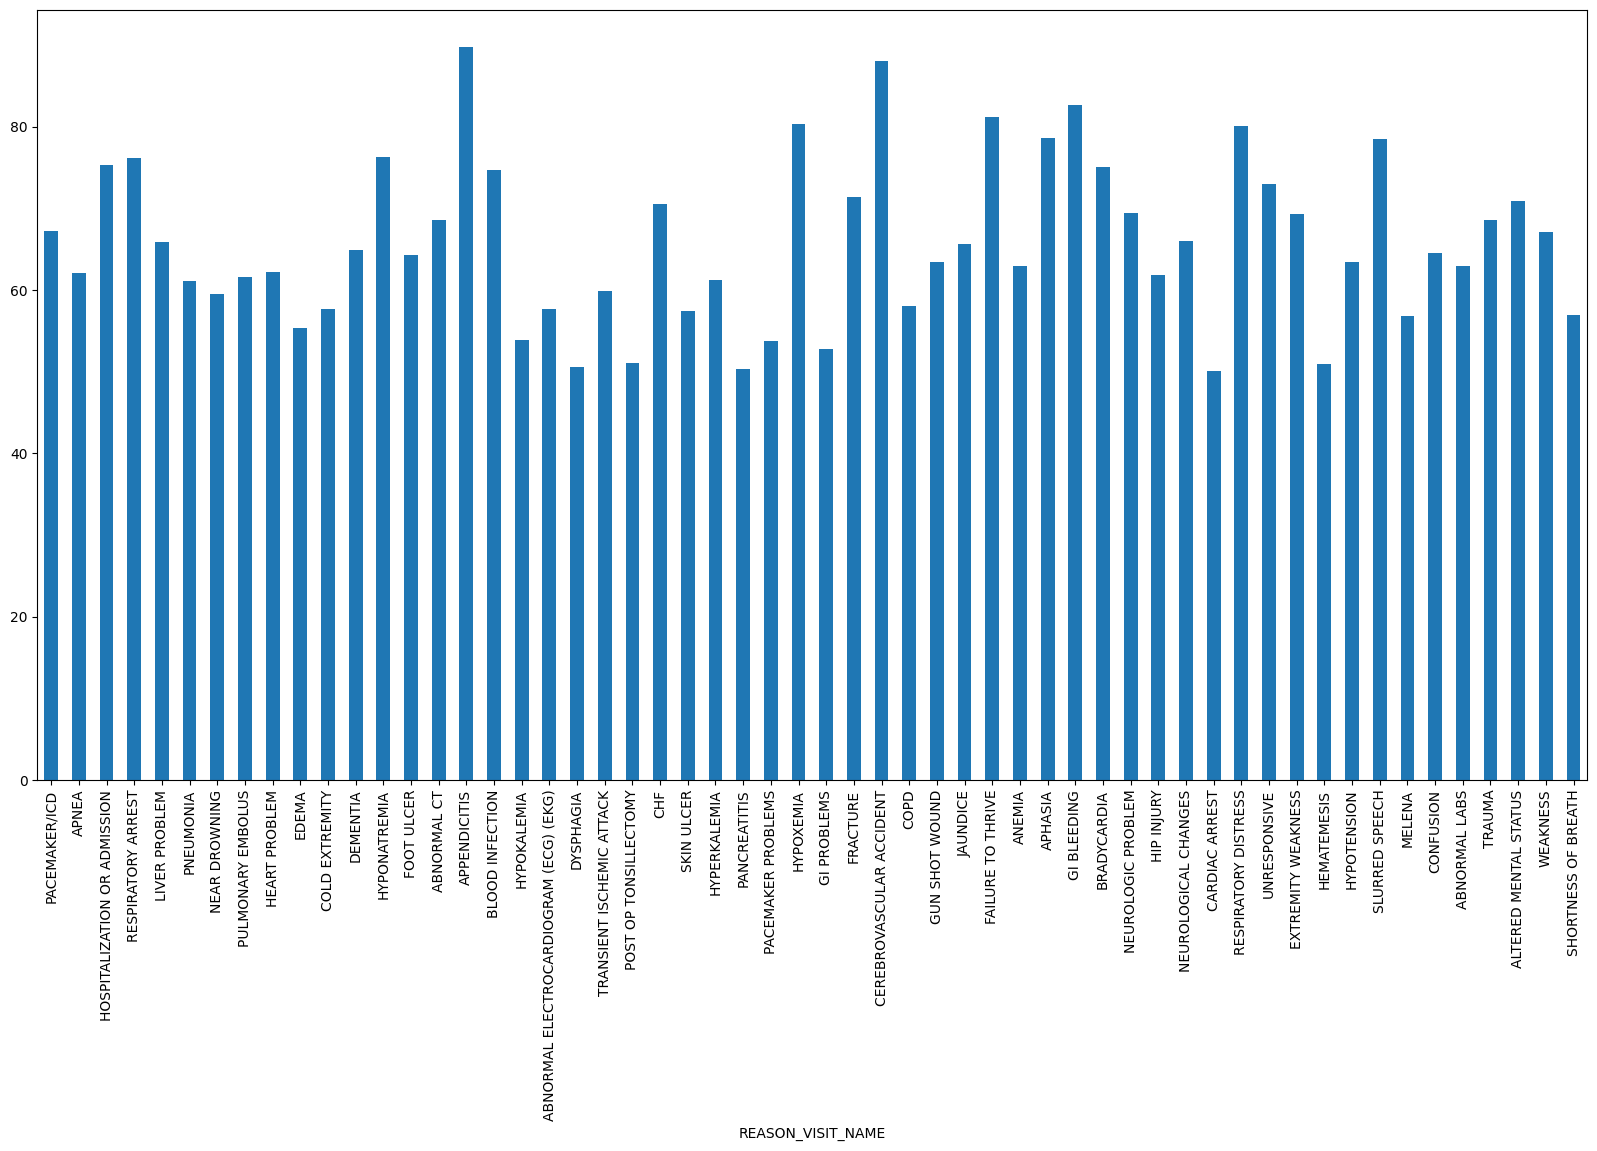

In [22]:
COVID_df['percentage_of_admittance'].plot(kind='bar', figsize=(20,10))

## Date/Time analysis

<Axes: xlabel='Year'>

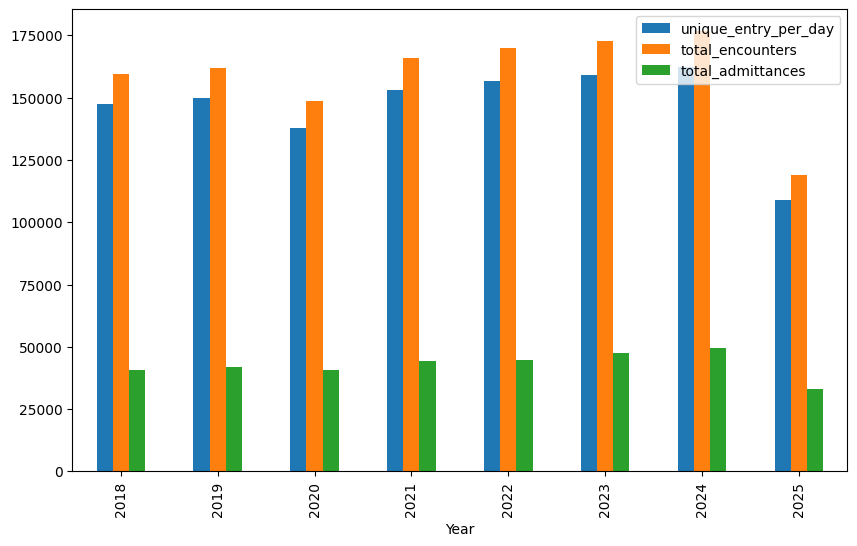

In [23]:
grouped_by_year = df.groupby(by = df['Date'].dt.year).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_year.plot(kind='bar', figsize=(10,6), xlabel='Year')

In [24]:
# Check what happend in Covid peak
df[(df['Date'].dt.year == 2020) & (df['Date'].dt.month >= 3) & (df['Date'].dt.month <= 6)].groupby(by='REASON_VISIT_NAME').agg('size').sort_values(ascending=False)

REASON_VISIT_NAME
ABDOMINAL PAIN              3490
CHEST PAIN                  2524
SHORTNESS OF BREATH         1667
FALL                        1539
FEVER                       1222
                            ... 
TRACHEOSTOMY TUBE CHANGE       1
ABNORMAL EEG                   1
WORD FINDING PROBLEMS          1
WOUND VAC PLACEMENT            1
ABNORMAL G TUBE                1
Length: 530, dtype: int64

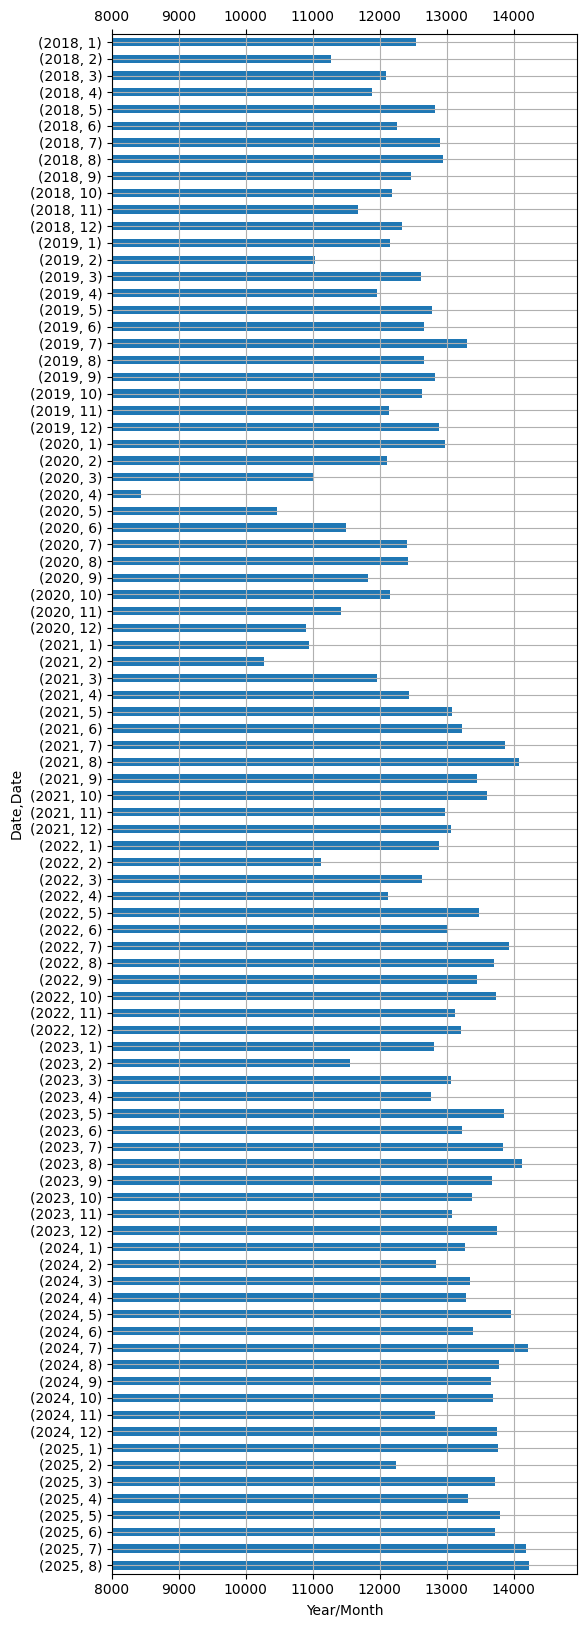

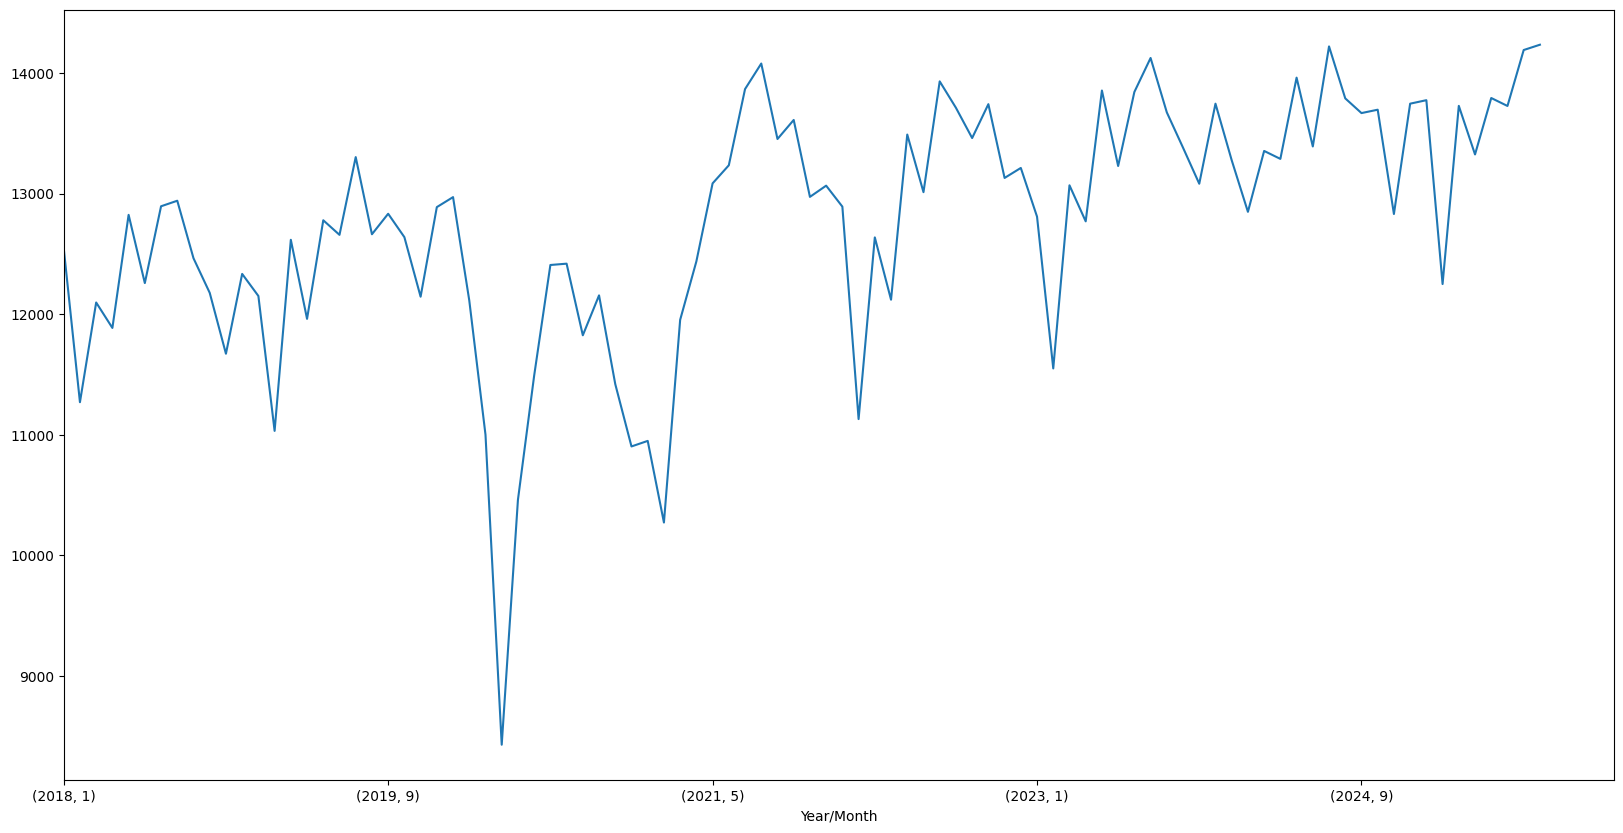

In [25]:
grouped_by_year_month = df.groupby(by = [df['Date'].dt.year, df['Date'].dt.month]).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
# for i in range(2018,2026):
#     grouped_by_year.loc[i].plot.bar()

ax1 = grouped_by_year_month['unique_entry_per_day'].plot(kind='barh', figsize = (6,20), xlabel='Year/Month', xlim=8000, grid=True)
ax1.invert_yaxis()
ax1.tick_params(top=True, labeltop=True)
plt.show()
ax2 = grouped_by_year_month['unique_entry_per_day'].plot(kind='line', figsize = (20,10), xlabel='Year/Month', xlim=0)
plt.show()



<Axes: xlabel='Month'>

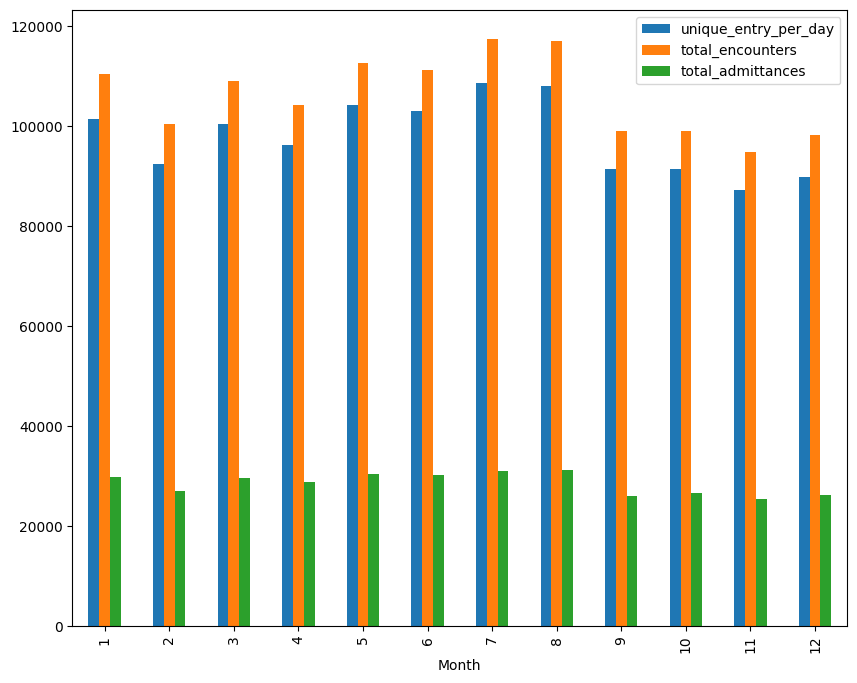

In [26]:
grouped_by_month = df.groupby(by = df['Date'].dt.month).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_month.plot(kind='bar', figsize = (10,8), xlabel='Month')

<Axes: xlabel='Day of the month'>

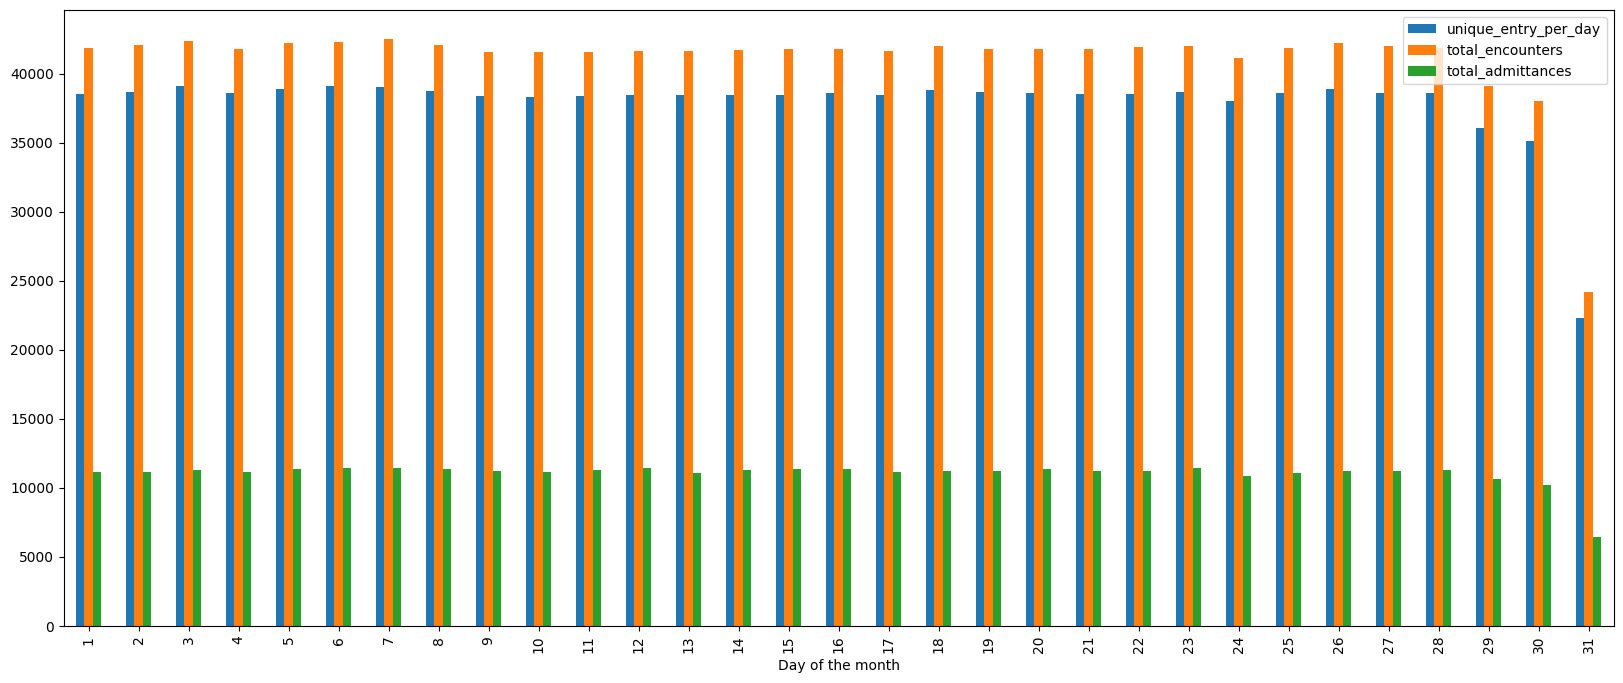

In [27]:
grouped_by_day = df.groupby(by = df['Date'].dt.day).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_day.plot(kind='bar', figsize = (20,8), xlabel='Day of the month')

<Axes: xlabel='Day of the week'>

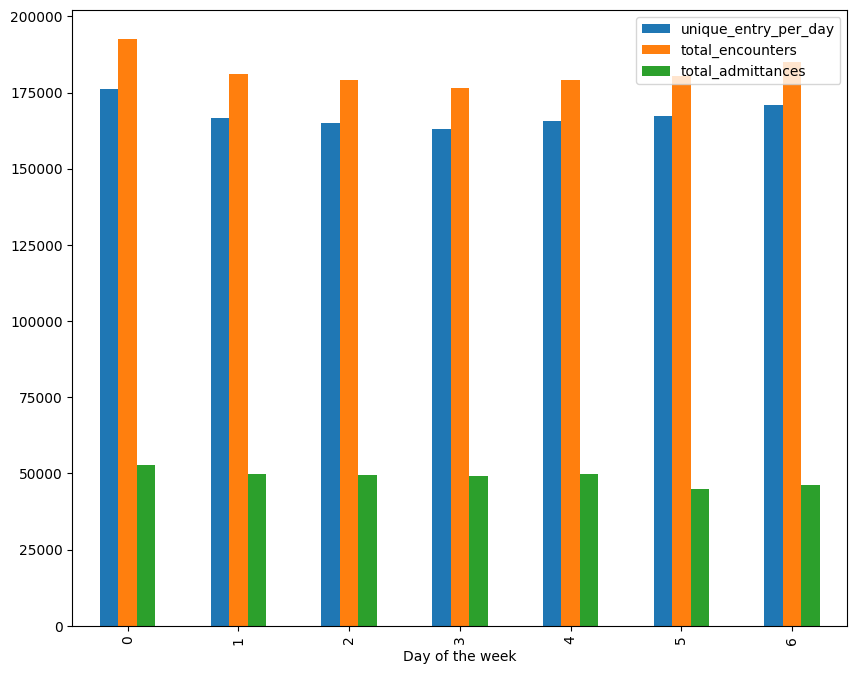

In [28]:
grouped_by_day_of_week = df.groupby(by = df['Date'].dt.day_of_week).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_day_of_week.plot(kind='bar', figsize = (10,8), xlabel='Day of the week')

In [29]:
grouped_by_year_reasons = df.groupby(by = [df['Date'].dt.year, df['REASON_VISIT_NAME']]).agg('size')
grouped_by_year_reasons = grouped_by_year_reasons.reset_index()
display(grouped_by_year_reasons[(grouped_by_year_reasons[0] > 500)],
        grouped_by_year_reasons[(grouped_by_year_reasons[0] > 500) & (grouped_by_year_reasons['REASON_VISIT_NAME']=='ALLERGIC REACTION')]
)

,Date,REASON_VISIT_NAME,0
4,2018,ABDOMINAL PAIN,12184
18,2018,ALCOHOL INTOXICATION,1625
20,2018,ALLERGIC REACTION,799
23,2018,ALTERED MENTAL STATUS,1063
34,2018,ANKLE INJURY,879
...,...,...,...
5169,2025,VAGINAL BLEEDING,918
5181,2025,VOMITING,2701
5183,2025,WEAKNESS,1895
5189,2025,WITHDRAWAL,536


,Date,REASON_VISIT_NAME,0
20,2018,ALLERGIC REACTION,799
692,2019,ALLERGIC REACTION,902
1352,2020,ALLERGIC REACTION,665
1996,2021,ALLERGIC REACTION,905
2659,2022,ALLERGIC REACTION,889
3339,2023,ALLERGIC REACTION,969
3996,2024,ALLERGIC REACTION,1072
4634,2025,ALLERGIC REACTION,700


Since there is no much insight in direct date analysis, lets try to see if there are any "seasonal illnesses"

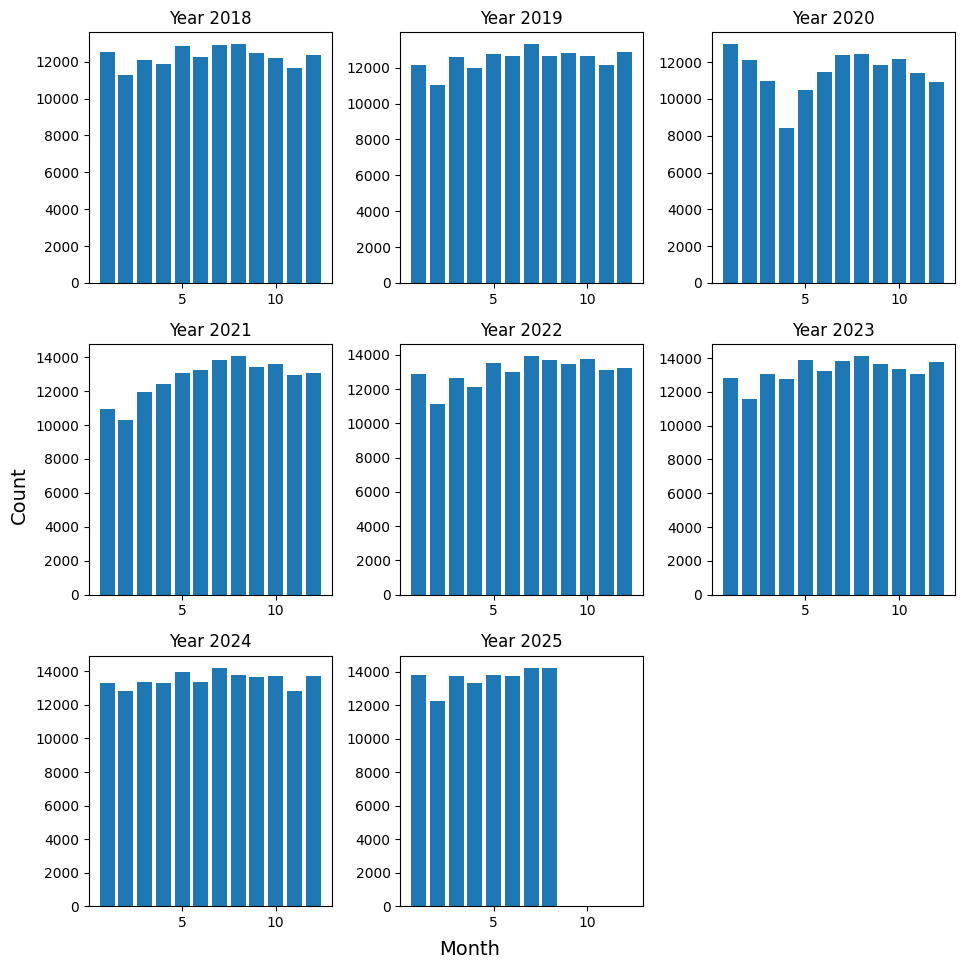

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(10,10))  
axes = axes.flatten() 

years = range(2018, 2026) 

for idx, j in enumerate(years):
    df_year = df[df['Date'].dt.year == j]
    test = df_year.groupby([df_year['Date'].dt.month, df_year['REASON_VISIT_NAME']]).size()

    count_of_reasons_per_month = [test.loc[i].sum() if i in test.index.levels[0] else 0 for i in range(1, 13)]

    axes[idx].bar(range(1, 13), count_of_reasons_per_month)
    axes[idx].set_title(f"Year {j}")
    # axes[idx].set_xlabel("Month")
    # axes[idx].set_ylabel("Count")

for ax in axes[len(years):]:
    fig.delaxes(ax)

fig.text(0.5, 0.04, 'Month', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Count', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.show()


In [31]:
test = df[df['Date'].dt.year==2022].groupby(by=[df['Date'].dt.month, df['REASON_VISIT_NAME']])['REASON_VISIT_NAME'].apply('size').to_frame()
test2 = test.rename(columns={'REASON_VISIT_NAME':'count_of_reason'}).reset_index()
test2[test2['count_of_reason']>500]

,Date,REASON_VISIT_NAME,count_of_reason
3,1,ABDOMINAL PAIN,1014
75,1,CHEST PAIN,788
343,1,SHORTNESS OF BREATH,537
421,2,ABDOMINAL PAIN,952
487,2,CHEST PAIN,698
825,3,ABDOMINAL PAIN,1084
892,3,CHEST PAIN,729
969,3,FALL,504
1238,4,ABDOMINAL PAIN,973
1310,4,CHEST PAIN,752


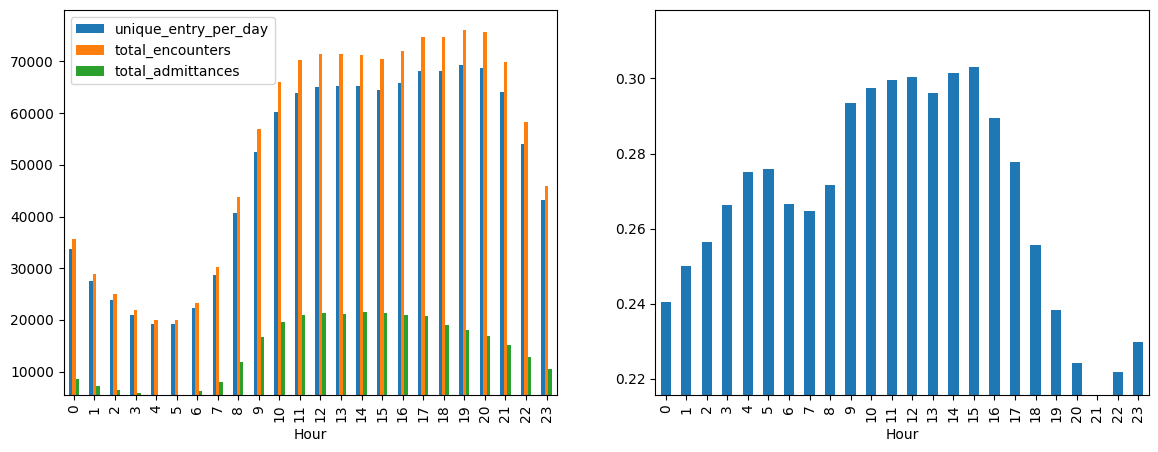

In [32]:
grouped_by_time = df.groupby(by = df['Hour']).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
grouped_by_time['admitance_rate'] = grouped_by_time['total_admittances'] / grouped_by_time['total_encounters']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns
grouped_by_time.iloc[:,:-1].plot(kind='bar', xlabel='Hour', ylim=grouped_by_time.iloc[:,:-1].min()['total_admittances'], ax=axes[0])
grouped_by_time['admitance_rate'].plot(kind='bar', ylim=grouped_by_time['admitance_rate'].min(), ax=axes[1])
plt.show()


## Analysis by site

,site,total_encounters,total_admittances,admittance_rate
Site,,,,
A,308478,339622,107210,0.315674
B,423139,463877,118092,0.254576
C,250370,267847,81899,0.305768
D,192323,202365,35136,0.173627


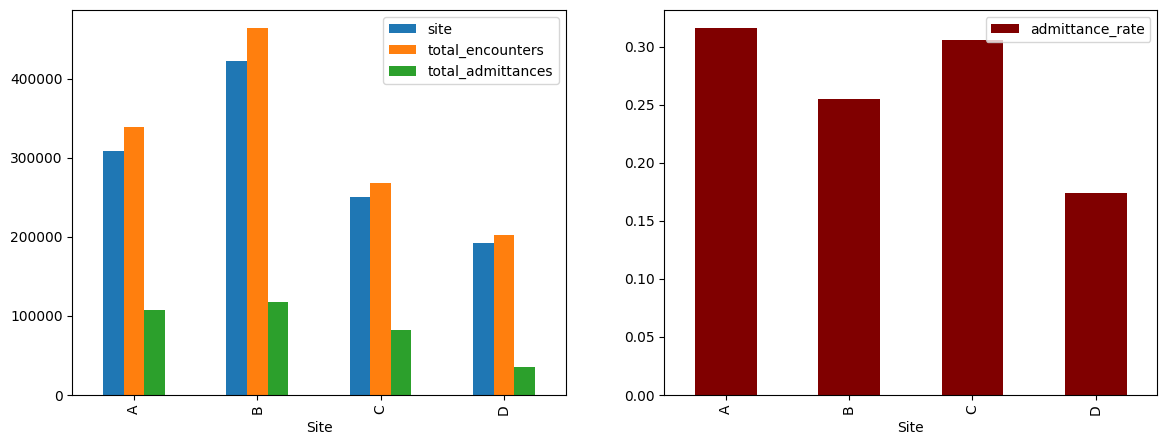

In [33]:
grouped_by_site = df.groupby(by='Site').agg(
    site = ('Site', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
grouped_by_site['admittance_rate'] = grouped_by_site['total_admittances'] /grouped_by_site['total_encounters']
display(grouped_by_site)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns
grouped_by_site.iloc[:,:-1].plot(kind='bar', ax=axes[0]) # finally some sort of imbalance
grouped_by_site['admittance_rate'].plot(kind='bar', ax=axes[1], legend=True, color='maroon')
plt.show()

## Misc

Why would 'ED Enc' and 'ED Enc Admitted' take values > 1 ?

In [34]:
df[df['ED Enc']>1].shape[0] / df.shape[0] # only 7%

0.07344312830513237

In [35]:
df[df['ED Enc Admitted']>1].shape[0] / df.shape[0]

0.00950856247498531

# Syndromic Grouping 

* Vectorizers: TF-IDF, W2V
* Clustering algorithms: K-Means

## TF-IDF

In [36]:
unique_reasons.sort()
unique_reasons

array(['ABDOMINAL AORTIC ANEURYSM', 'ABDOMINAL CRAMPING',
       'ABDOMINAL DISTENTION', 'ABDOMINAL INJURY', 'ABDOMINAL PAIN',
       'ABN FOLLOW-UP', 'ABNORMAL CT', 'ABNORMAL CXR', 'ABNORMAL EEG',
       'ABNORMAL ELECTROCARDIOGRAM (ECG) (EKG)', 'ABNORMAL G TUBE',
       'ABNORMAL HEART SCREEN', 'ABNORMAL LABS', 'ABNORMAL PET SCAN',
       'ABRASION', 'ABSCESS', 'ABSTRACT', 'ACCESSORY NIPPLE',
       'ACUTE RENAL FAILURE', 'ADDICTION PROBLEM', 'ADDISONS DISEASE',
       'ADENOPATHY', 'ADJUSTMENT ISSUES', 'ADRENAL CANCER',
       'ADVANCE CARE PLANNING', 'AGGRESSIVE BEHAVIOR', 'AGITATION',
       'AICD PROBLEM', 'AIRWAY OBSTRUCTION', 'ALCOHOL INTOXICATION',
       'ALCOHOL PROBLEM', 'ALLERGIC REACTION', 'ALLERGIC RHINITIS',
       'ALLERGIES', 'ALLIED HEALTH VISIT', 'ALOPECIA',
       'ALS (AMYOTROPHIC LATERAL SCLEROSIS)', 'ALTERED MENTAL STATUS',
       'AMENORRHEA', 'AMPUTATION', 'ANAL FISSURE', 'ANAL FISTUAL',
       'ANAL ITCHING', 'ANEMIA', 'ANEMIA MANAGEMENT', 'ANEURYSM', 'ANGER'

In [40]:
vectorizer = TfidfVectorizer(ngram_range=(1,2), lowercase=False)

X = vectorizer.fit_transform(unique_reasons) # return a sparse matrix where row -> reason, column -> embedding vector
vectorizer.get_feature_names_out().tolist()[:15]

['19',
 '19 EXPOSURE',
 '19 INFORMATION',
 '19 OUTPATIENT',
 'ABDOMINAL',
 'ABDOMINAL AORTIC',
 'ABDOMINAL CRAMPING',
 'ABDOMINAL DISTENTION',
 'ABDOMINAL INJURY',
 'ABDOMINAL PAIN',
 'ABN',
 'ABN FOLLOW',
 'ABNORMAL',
 'ABNORMAL CT',
 'ABNORMAL CXR']

In [29]:
X[:,vectorizer.vocabulary_['ABDOMINAL']].toarray().flatten().nonzero()

(array([0, 1, 2, 3, 4]),)

In [33]:
unique_reasons[X[:,vectorizer.vocabulary_['ABDOMINAL']].toarray().flatten().nonzero()]

array(['ABDOMINAL AORTIC ANEURYSM', 'ABDOMINAL CRAMPING',
       'ABDOMINAL DISTENTION', 'ABDOMINAL INJURY', 'ABDOMINAL PAIN'],
      dtype=object)

In [45]:
idxs_of_keyword = X[:,vectorizer.vocabulary_['ABDOMINAL']].toarray().flatten().nonzero()
idxs_of_keyword

(array([0, 1, 2, 3, 4]),)

In [35]:
vectorizer.vocabulary_['ABDOMINAL']

4

In [153]:
unique_reasons_containing_keyword = unique_reasons[X[:,vectorizer.vocabulary_['ABDOMINAL']].toarray().flatten().nonzero()]
unique_reasons_containing_keyword

array(['ABDOMINAL AORTIC ANEURYSM', 'ABDOMINAL CRAMPING',
       'ABDOMINAL DISTENTION', 'ABDOMINAL INJURY', 'ABDOMINAL PAIN'],
      dtype=object)

## BioWordVec

In [137]:
from gensim.models import KeyedVectors
import numpy as np

MODEL_PATH = "BioWordVec_PubMed_MIMICIII_d200.vec.bin"
DIM = 200

print("Loading BioWordVec vectors...")
model = KeyedVectors.load_word2vec_format(MODEL_PATH, binary=True, limit=int(3e6))
print("Loaded.")




Loading BioWordVec vectors...
Loaded.


In [138]:
def sentence_vector(text: str) -> np.ndarray:
    tokens = text.lower().split()
    vectors = [model[word] for word in tokens if word in model]

    if not vectors:
        return np.zeros(DIM, dtype=np.float32)

    return np.mean(vectors, axis=0)

# Example
unique_reasons

embeddings = np.vstack([sentence_vector(t) for t in unique_reasons])
print(embeddings.shape)
embeddings

(868, 200)


array([[ 0.08138634,  0.3786633 , -0.13939933, ..., -0.04030667,
        -0.37897667, -0.48795334],
       [-0.0022035 ,  0.17342   , -0.330165  , ...,  0.18165   ,
        -0.33754498, -0.14922   ],
       [-0.26287147,  0.2480585 , -0.37567502, ...,  0.38220498,
        -0.4081    , -0.416585  ],
       ...,
       [ 0.07571997, -0.29901996, -0.509715  , ..., -0.09513944,
        -0.24302332, -0.64597005],
       [ 0.0051215 ,  0.399145  , -0.38064998, ..., -0.089821  ,
        -0.30452   , -0.24388951],
       [ 0.023798  ,  0.57799995, -0.50396   , ...,  0.06704   ,
        -0.0851275 ,  0.1219155 ]], shape=(868, 200), dtype=float32)

In [139]:
X.shape, embeddings.shape

((868, 1648), (868, 200))

## K-Means

In [150]:
model = KMeans(n_clusters=17, random_state=1) 
model_weighted = KMeans(n_clusters=6, random_state=1) 
model_w2v = KMeans(n_clusters=20, random_state=1)
model_w2v_weighted = KMeans(n_clusters=5, random_state=1)


pred_cluster = model.fit_predict(X) # UNWEIGHTED 
pred_cluster_weighted = model_weighted.fit_predict(X, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist()) 
pred_cluster_w2v = model_w2v.fit_predict(embeddings) # UNWEIGHTED 
pred_cluster_weighted_w2v = model_w2v_weighted.fit_predict(embeddings, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist()) 


In [142]:
pred_cluster[idxs_of_keyword], pred_cluster_weighted[idxs_of_keyword] # We see that if the keyward cancer is included then they are all clustered together

(array([1, 1, 1, 7, 3], dtype=int32), array([2, 2, 2, 2, 5], dtype=int32))

In [151]:
pred_cluster_w2v[idxs_of_keyword], pred_cluster_weighted_w2v[idxs_of_keyword]

(array([ 1, 18,  1, 12, 18], dtype=int32), array([0, 1, 1, 0, 1], dtype=int32))

In [154]:
unique_reasons_containing_keyword[np.where(pred_cluster[idxs_of_keyword]!=4)]

array(['ABDOMINAL AORTIC ANEURYSM', 'ABDOMINAL CRAMPING',
       'ABDOMINAL DISTENTION', 'ABDOMINAL INJURY', 'ABDOMINAL PAIN'],
      dtype=object)

### Optimization of numbers of clusters

https://medium.com/@jwbtmf/visualizing-data-using-k-means-clustering-unsupervised-machine-learning-8b59eabfcd3d

https://medium.com/@jeffzyme/understanding-inertia-distortion-and-silhouette-scores-and-their-differences-key-metrics-for-458fe28ce2aa

Three "standard" measures for analysis of clustering algorithms:
* **Inertia:** Measures the compactness of the clusters i.e. how close the points of each cluster is to their respective centroid. 
$$\text{INERTIA} =\sum_{C\in\text{CLUSTERS}} \, \sum_{x\in C}\Vert x-\text{centroid}(C)\Vert^2$$
It’s particularly useful in the Elbow Method when combined with distortion.

* **Distortion:** Lower distortion scores suggest points are tightly grouped, but too many clusters may imply overfitting. 
$$\text{Distortion Score} = \frac{1}{N}\sum_{C\in\text{CLUSTERS}} \, \sum_{x\in C}\Vert x-\text{centroid}(C)\Vert$$

* **Silhouette:** High average silhouette scores across all points suggest strong clustering, with distinct separation between clusters. This score is particularly insightful for comparing different clustering approaches, as it evaluates both within-cluster tightness and inter-cluster separation. For $x\in C$
$$\text{Silhouette Score}=\frac{b-a}{\max(a,b)}$$
 where $a$ is the average distance of $x$ to every other point in its cluster and $b$ is the average from all the points to the neighboring cluster (i.e. the cluster with the closer centroid).

The overall Silhouette Score is the average of silhouette scores for all points, producing a range from −1 to 1:

*    Values close to 1 indicate well-separated clusters,
*    Values near 0 suggest overlapping clusters,
*    Negative values signal possible misclassification.

In [145]:
def distortion_score(model: KMeans, X: np.ndarray | scipy.sparse._csr.csr_matrix) -> float:
    labels = model.labels_
    centers = model.cluster_centers_
    N = X.shape[0]
    ds = 1/N * np.linalg.norm((X.toarray() - centers[labels])) if type(X) == scipy.sparse._csr.csr_matrix else 1/N * np.linalg.norm((X - centers[labels]))
    return ds

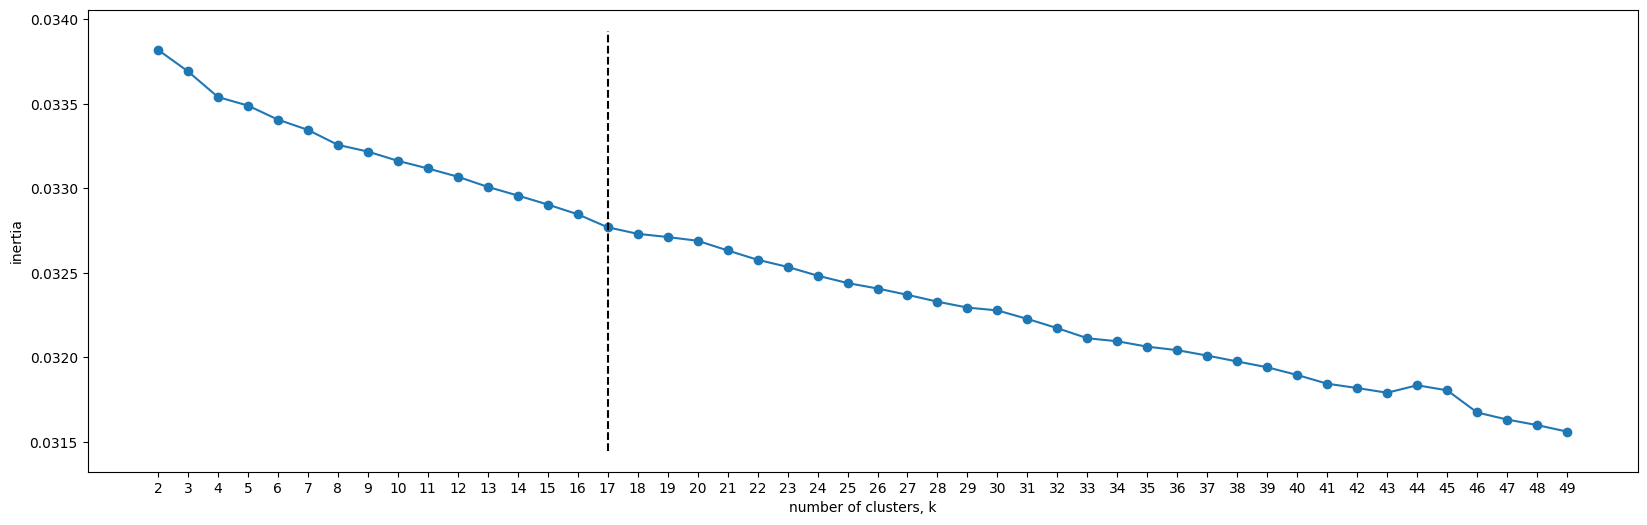

In [116]:
# Opt. for unweighted K-Means with TF-IDF

ks = range(2, 50, 1)
inertias = []
distortions = []
silhouettes = []

for k in ks:
    model = KMeans(n_clusters=k, random_state=1)
    model.fit(X)
    inertias.append(model.inertia_)
    distortions.append(distortion_score(model, X))
    silhouettes.append( silhouette_score(X, model.predict(X)) )

kn = KneeLocator(ks, distortions, curve='convex', direction='decreasing')

# Plot ks vs inertias
plt.figure(figsize=(20, 6))
# plt.plot(ks, inertias, '-o')
plt.plot(ks, distortions, '-o')
# plt.plot(ks, silhouettes, '-o')
plt.vlines(list(kn.all_knees), plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='black')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

In [117]:
kn.knee

np.int64(17)

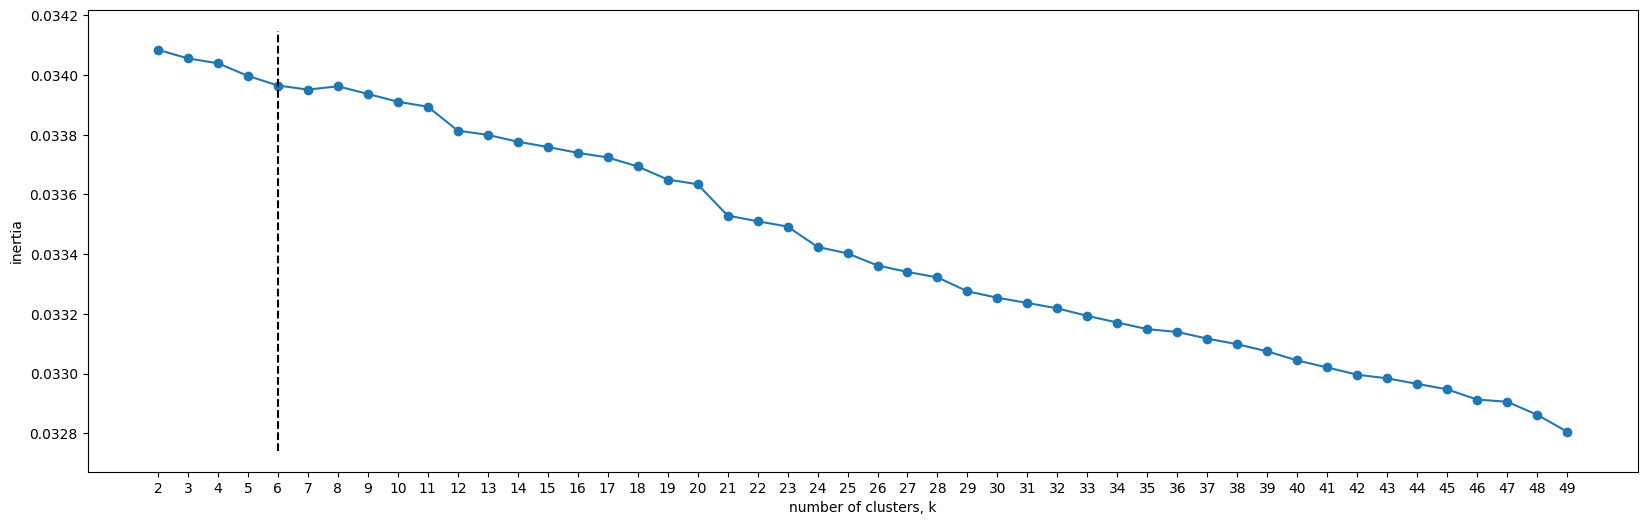

In [118]:
# Opt. for weighted K-Means with TF-IDF

ks = range(2, 50, 1)
inertias = []
distortions = []
silhouettes = []

for k in ks:

    model = KMeans(n_clusters=k, random_state=1)
    model.fit(X, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist())
    inertias.append(model.inertia_)
    distortions.append(distortion_score(model, X))
    silhouettes.append( silhouette_score(X, model.predict(X)) )

kn = KneeLocator(ks, distortions, curve='convex', direction='decreasing')

# Plot ks vs inertias
plt.figure(figsize=(20, 6))
# plt.plot(ks, inertias, '-o')
plt.plot(ks, distortions, '-o')
# plt.plot(ks, silhouettes, '-o')
plt.vlines(list(kn.all_knees), plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='black')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

In [120]:
kn.all_knees

{np.int64(6)}

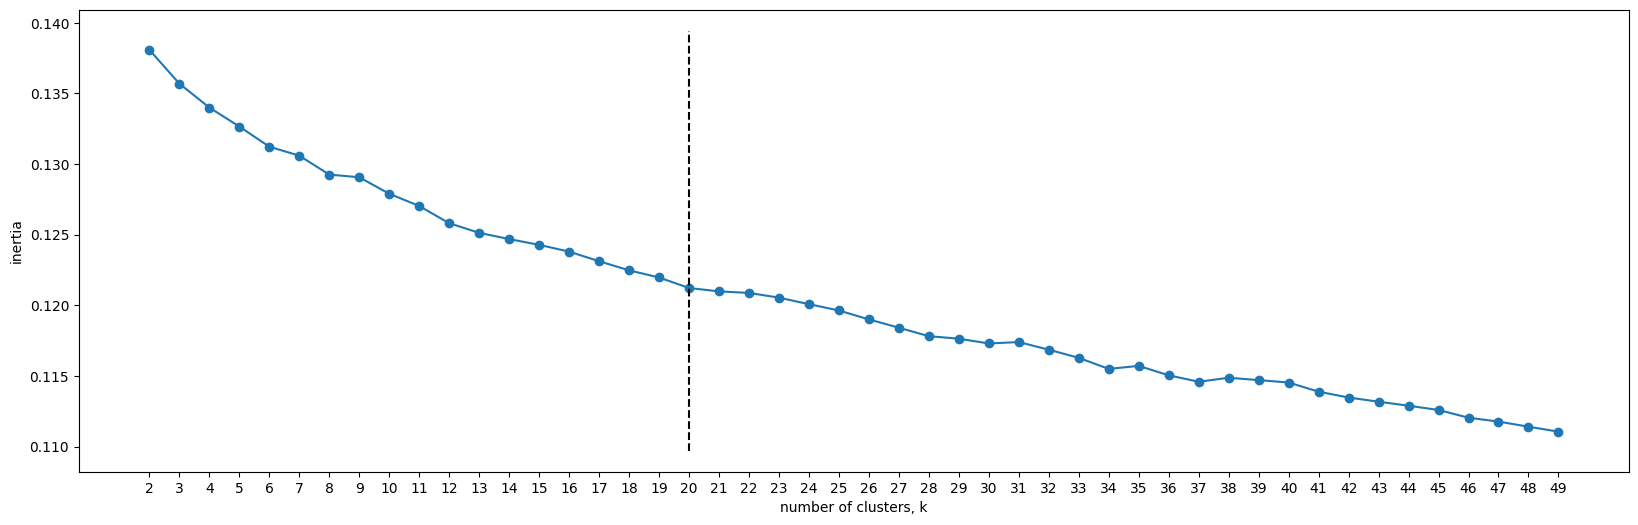

In [146]:
# Opt. for unweighted K-Means with w2v

ks = range(2, 50, 1)
inertias = []
distortions = []
silhouettes = []

for k in ks:

    model = KMeans(n_clusters=k, random_state=1)
    model.fit(embeddings)
    inertias.append(model.inertia_)
    distortions.append(distortion_score(model, embeddings))
    silhouettes.append( silhouette_score(embeddings, model.predict(embeddings)) )

kn = KneeLocator(ks, distortions, curve='convex', direction='decreasing')

# Plot ks vs inertias
plt.figure(figsize=(20, 6))
# plt.plot(ks, inertias, '-o')
plt.plot(ks, distortions, '-o')
# plt.plot(ks, silhouettes, '-o')
plt.vlines(list(kn.all_knees), plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='black')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

In [147]:
kn.knee

np.int64(20)

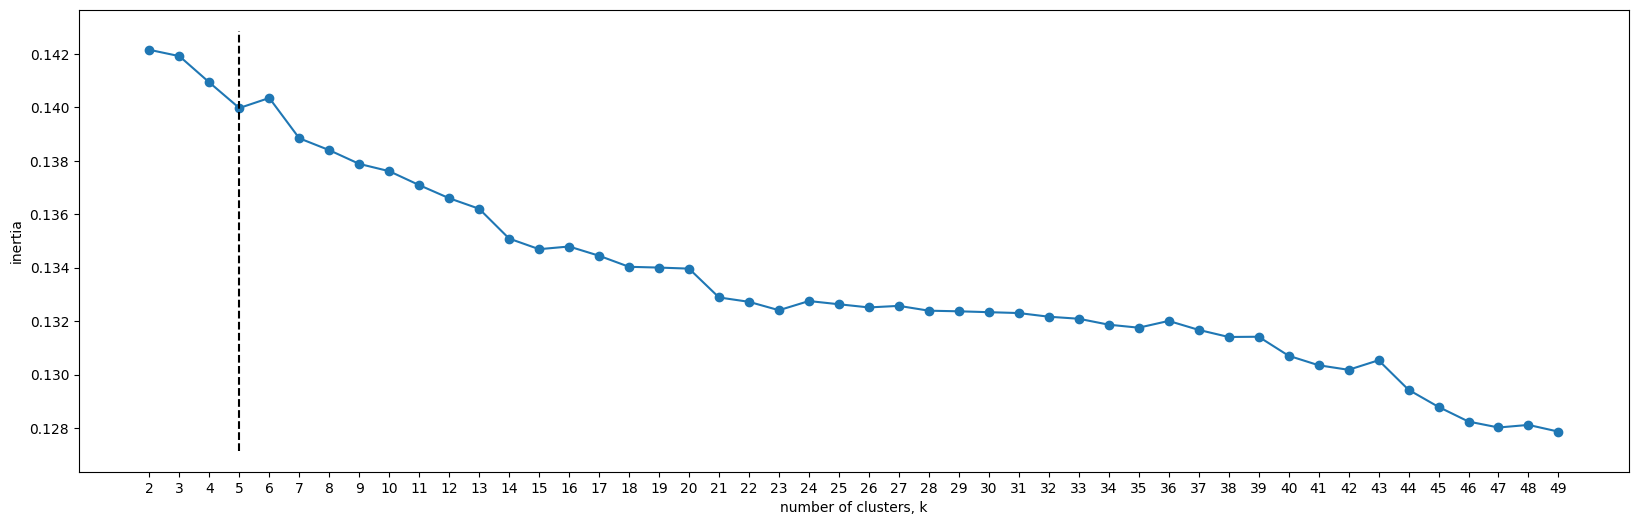

In [148]:
# Opt. for weighted K-Means with w2v

ks = range(2, 50, 1)
inertias = []
distortions = []
silhouettes = []

for k in ks:

    model = KMeans(n_clusters=k, random_state=1)
    model.fit(embeddings, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist())
    inertias.append(model.inertia_)
    distortions.append(distortion_score(model, embeddings))
    silhouettes.append( silhouette_score(embeddings, model.predict(embeddings)) )

kn = KneeLocator(ks, distortions, curve='convex', direction='decreasing')

# Plot ks vs inertias
plt.figure(figsize=(20, 6))
# plt.plot(ks, inertias, '-o')
plt.plot(ks, distortions, '-o')
# plt.plot(ks, silhouettes, '-o')
plt.vlines(list(kn.all_knees), plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='black')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

In [149]:
kn.all_knees

{np.int64(5)}

### Qualitative analysis on the cluster-optimized model.

In [155]:
def remap(reason:str, model, model_weighted, X) -> Tuple[int, int]:
    '''
    Input:
        str - the reason of the encounter 
    Output:
        Tuple[int, int] - the corresponding cluster of the unweighted and weighted models respectively
    '''
    idx_of_reason = np.where(unique_reasons==reason)
    return model.predict(X[idx_of_reason])[0], model_weighted.predict(X[idx_of_reason])[0]

# remap('ABDOMINAL PAIN', model=model, model_weighted=model_weighted)


In [156]:
remap('ABDOMINAL PAIN', model=model_w2v, model_weighted=model_w2v_weighted, X=embeddings)


(np.int32(18), np.int32(1))

In [157]:
unique_vals = df["REASON_VISIT_NAME"].unique()
results = {val: remap(val, model, model_weighted, X)[0] for val in unique_vals}
weighted_results = {val: remap(val, model, model_weighted, X)[1] for val in unique_vals}
results_w2v = {val: remap(val, model_w2v, model_w2v_weighted, embeddings)[0] for val in unique_vals}
weighted_results_w2v = {val: remap(val, model_w2v, model_w2v_weighted, embeddings)[1] for val in unique_vals}



df["Cluster_UM"] = df["REASON_VISIT_NAME"].map(results)
df["Cluster_WM"] = df["REASON_VISIT_NAME"].map(weighted_results)

df["Cluster_UM_w2v"] = df["REASON_VISIT_NAME"].map(results_w2v)
df["Cluster_WM_w2v"] = df["REASON_VISIT_NAME"].map(weighted_results_w2v)

In [158]:
df

,Site,Date,Hour,REASON_VISIT_NAME,ED Enc,ED Enc Admitted,Cluster_UM,Cluster_WM,Cluster_UM_w2v,Cluster_WM_w2v
0,A,2018-01-01,0,BREATHING PROBLEM,1,1,2,2,2,2
1,A,2018-01-01,0,BURN,1,0,1,2,12,0
2,A,2018-01-01,0,SHAKING,1,1,1,2,5,2
3,A,2018-01-01,0,VOMITING,1,0,1,2,4,4
4,A,2018-01-01,1,FROSTBITE,1,0,1,2,12,0
...,...,...,...,...,...,...,...,...,...,...
1174305,D,2025-08-31,22,KNEE INJURY,1,0,7,2,17,0
1174306,D,2025-08-31,23,CHEST PAIN,1,0,3,5,18,1
1174307,D,2025-08-31,23,DIZZINESS,1,0,1,3,4,4
1174308,D,2025-08-31,23,FINGER PAIN,1,0,3,5,18,1


In [159]:
grouped_by_UM_clusters = df.groupby(by='Cluster_UM').agg('size')
grouped_by_WM_clusters = df.groupby(by='Cluster_WM').agg('size')

grouped_by_UM_w2v_clusters = df.groupby(by='Cluster_UM_w2v').agg('size')
grouped_by_WM_w2v_clusters = df.groupby(by='Cluster_WM_w2v').agg('size')


In [160]:
display(grouped_by_UM_clusters.describe())
display(grouped_by_WM_clusters.describe())
display(grouped_by_UM_w2v_clusters.describe())
display(grouped_by_WM_w2v_clusters.describe())

count        17.000000
mean      69077.058824
std      172414.427496
min           6.000000
25%         254.000000
50%        5987.000000
75%       15676.000000
max      667614.000000
dtype: float64

count         6.000000
mean     195718.333333
std      311263.716296
min        2505.000000
25%        7993.000000
50%       33613.000000
75%      252050.500000
max      780263.000000
dtype: float64

count        20.000000
mean      58715.500000
std       80817.436295
min         428.000000
25%        9883.750000
50%       23241.000000
75%       69174.750000
max      320888.000000
dtype: float64

count         5.00000
mean     234862.00000
std      149356.98055
min       46042.00000
25%      159255.00000
50%      207503.00000
75%      333097.00000
max      428413.00000
dtype: float64

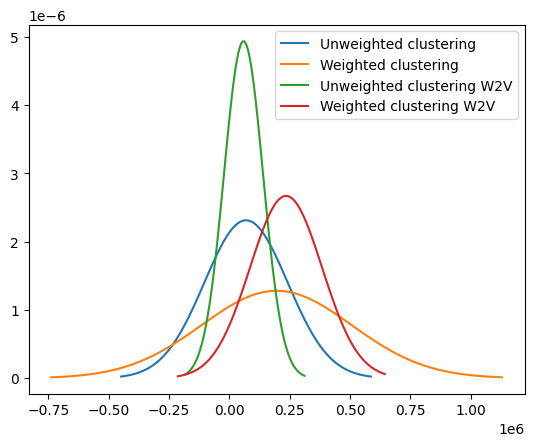

In [161]:
mu1 = grouped_by_UM_clusters.mean()
sigma1 = grouped_by_UM_clusters.std()
variance1 = sigma1 ** 2

mu2 = grouped_by_WM_clusters.mean()
sigma2 = grouped_by_WM_clusters.std()
variance2 = sigma2 ** 2

mu3 = grouped_by_UM_w2v_clusters.mean()
sigma3 = grouped_by_UM_w2v_clusters.std()
variance1 = sigma3 ** 2

mu4 = grouped_by_WM_w2v_clusters.mean()
sigma4 = grouped_by_WM_w2v_clusters.std()
variance4 = sigma4 ** 2

x1 = np.linspace(mu1 - 3*sigma1, mu1 + 3*sigma1, 100)
x2 = np.linspace(mu2 - 3*sigma2, mu2 + 3*sigma2, 100)
x3 = np.linspace(mu3 - 3*sigma3, mu1 + 3*sigma3, 100)
x4 = np.linspace(mu4 - 3*sigma4, mu2 + 3*sigma4, 100)

plt.plot(x1, stats.norm.pdf(x1, mu1, sigma1), label='Unweighted clustering')
plt.plot(x2, stats.norm.pdf(x2, mu2, sigma2), label='Weighted clustering')
plt.plot(x3, stats.norm.pdf(x3, mu3, sigma3), label='Unweighted clustering W2V')
plt.plot(x4, stats.norm.pdf(x4, mu4, sigma4), label='Weighted clustering W2V')
plt.legend()
plt.show()

SIDENOTE 
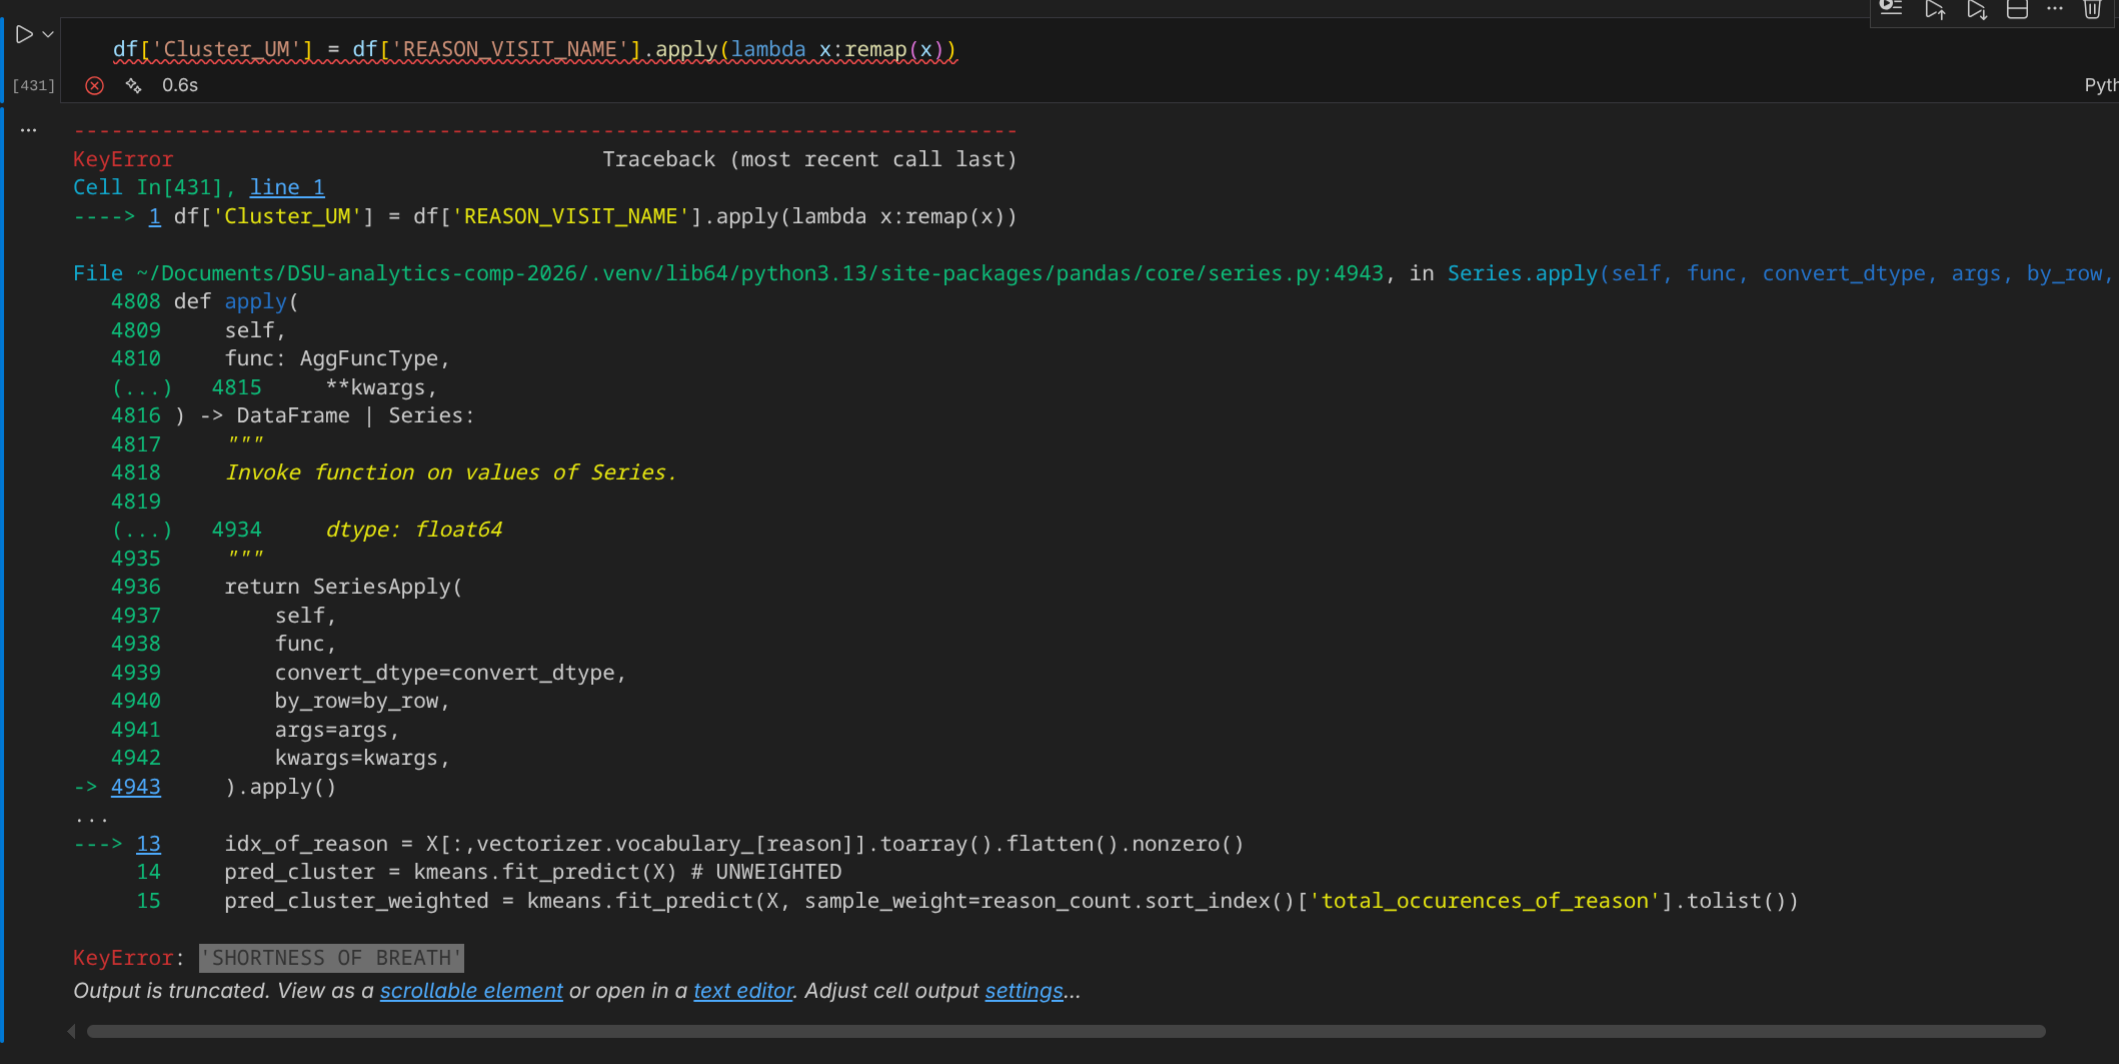

THE BUG IS DUE TO THE FACT THAT THE NGRAM RANGE GOES UP TO 2, AN EASY FIX IS JUST TO MAKE THE RANGE GO UP TO 3, DISCUSS WITH THE OTHERS IF THAT COULD CREATE A LOGICAL ERROR

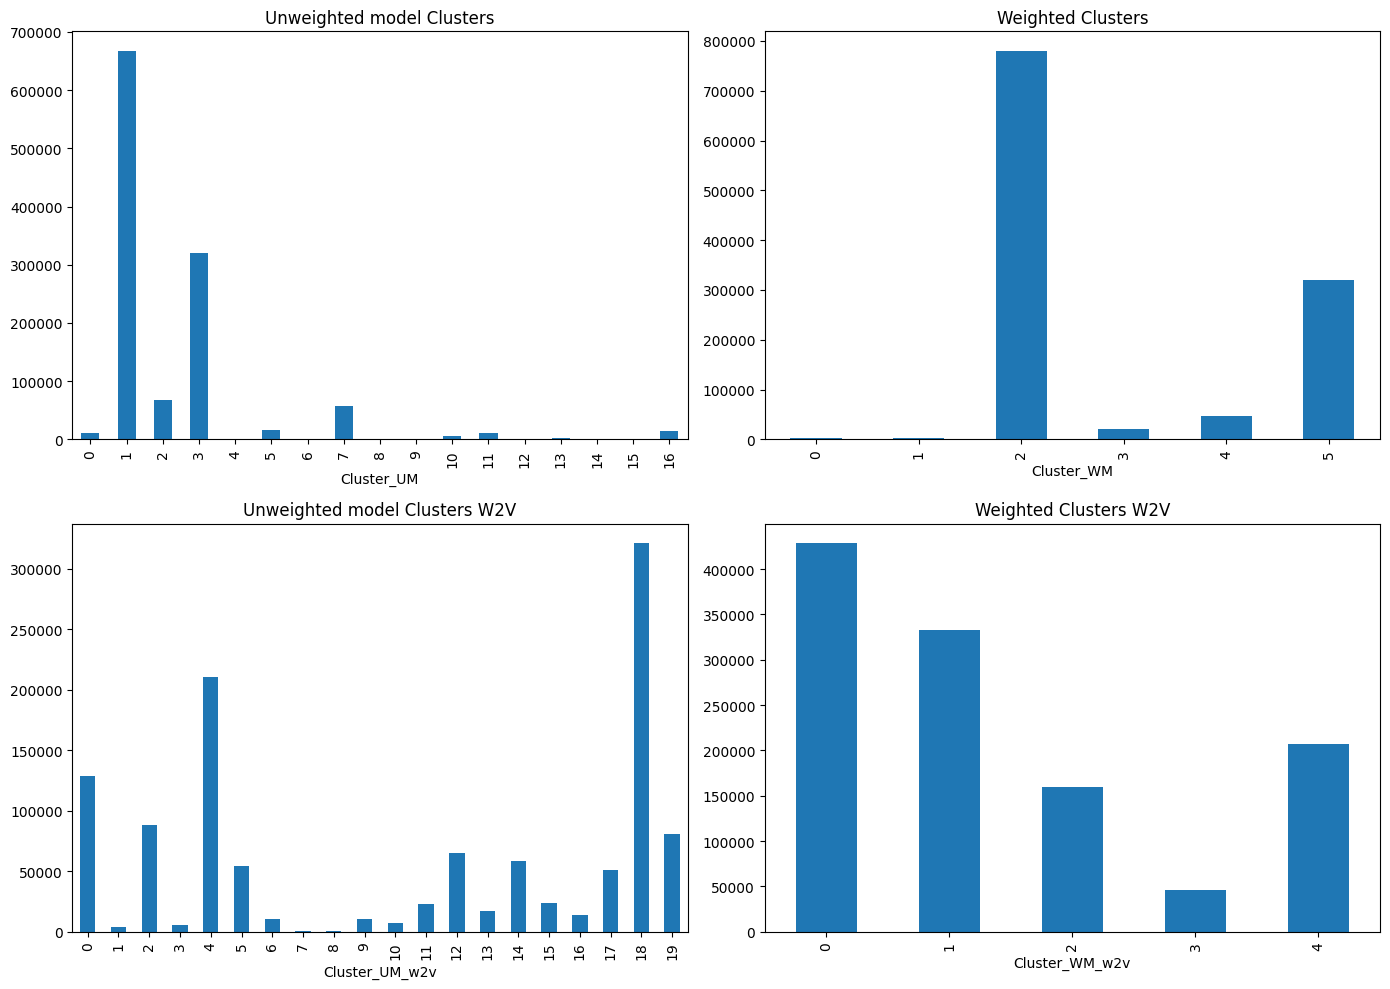

In [162]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

grouped_by_UM_clusters.plot(kind='bar', ax=axes[0,0], title='Unweighted model Clusters')
grouped_by_WM_clusters.plot(kind='bar', ax=axes[0,1], title='Weighted Clusters')

grouped_by_UM_w2v_clusters.plot(kind='bar', ax=axes[1,0], title='Unweighted model Clusters W2V')
grouped_by_WM_w2v_clusters.plot(kind='bar', ax=axes[1,1], title='Weighted Clusters W2V')

plt.tight_layout()
plt.show()

In [180]:
grouped_by_UM_clusters_unique_reasons = df.groupby(by=['Cluster_UM'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_UM_clusters_unique_reasons['count'] = grouped_by_UM_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_UM_clusters_unique_reasons

,REASON_VISIT_NAME,count
Cluster_UM,,
0,"[FOREIGN BODY IN NOSE, FOREIGN BODY SWALLOWED,...",9
1,"[BURN, SHAKING, VOMITING, FROSTBITE, SEIZURES,...",627
2,"[BREATHING PROBLEM, DERM PROBLEM, RECTAL PROBL...",41
3,"[ABDOMINAL PAIN, LEG PAIN, BACK PAIN, FLANK PA...",44
4,"[LUNG CANCER, CANCER, RECTAL CANCER, COLON CAN...",14
5,"[EVALUATION OF SEXUAL ASSAULT, EVALUATION OF C...",12
6,"[ESOPHAGITIS, EOSINOPHILIC ESOPHAGITIS]",2
7,"[CLOSED HEAD INJURY, FOOT INJURY, FACIAL INJUR...",30
8,"[RECTAL PROLAPSE, BLADDER PROBLEM, BLADDER DYS...",8


In [179]:
grouped_by_WM_clusters_unique_reasons = df.groupby(by=['Cluster_WM'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_WM_clusters_unique_reasons['count'] = grouped_by_WM_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_WM_clusters_unique_reasons

,REASON_VISIT_NAME,count
Cluster_WM,,
0,"[COVID 19 INFORMATION, COVID 19 EXPOSURE, COVI...",4
1,"[MOUTH LESION, MOUTH/LIP PROBLEM, MOUTH PAIN, ...",4
2,"[BREATHING PROBLEM, BURN, SHAKING, VOMITING, F...",817
3,[DIZZINESS],1
4,[FALL],1
5,"[ABDOMINAL PAIN, LEG PAIN, BACK PAIN, FLANK PA...",41


In [176]:
grouped_by_UM_w2v_clusters_unique_reasons = df.groupby(by=['Cluster_UM_w2v'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_UM_w2v_clusters_unique_reasons['count'] = grouped_by_UM_w2v_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_UM_w2v_clusters_unique_reasons

,REASON_VISIT_NAME,count
Cluster_UM_w2v,,
0,"[FALL, NaN, COLD EXPOSURE, BLOOD PRESSURE, EAR...",136
1,"[NASAL CONGESTION, ABDOMINAL AORTIC ANEURYSM, ...",19
2,"[BREATHING PROBLEM, ANXIETY, RECTAL PROBLEM, R...",78
3,"[RASH, HIVES, PALLOR, THRUSH, DIAPER RASH, CYA...",7
4,"[VOMITING, FEVER, COUGH, SORE THROAT, HEADACHE...",29
5,"[SHAKING, SEIZURES, WEAKNESS, AGITATION, UNRES...",53
6,"[ALLERGIC REACTION, ANGIOEDEMA, ASTHMA, CROUP,...",27
7,"[GOUT, PSORIATIC ARTHRITIS, RHEUMATOID ARTHRIT...",23
8,"[BREAST MASS, BREAST DISCHARGE, BREAST PROBLEM...",30


In [ ]:
grouped_by_WM_w2v_clusters_unique_reasons = df.groupby(by=['Cluster_WM_w2v'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_WM_w2v_clusters_unique_reasons['count'] = grouped_by_WM_w2v_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_WM_w2v_clusters_unique_reasons

,REASON_VISIT_NAME,count
Cluster_WM_w2v,,
0,"[BURN, FROSTBITE, SEIZURES, LACERATION, NEAR S...",706
1,"[ABDOMINAL PAIN, LEG PAIN, BACK PAIN, FLANK PA...",52
2,"[BREATHING PROBLEM, SHAKING, ANXIETY, COPD, SH...",50
3,[FALL],1
4,"[VOMITING, FEVER, SYNCOPE, HEADACHE, FLU-LIKE ...",59


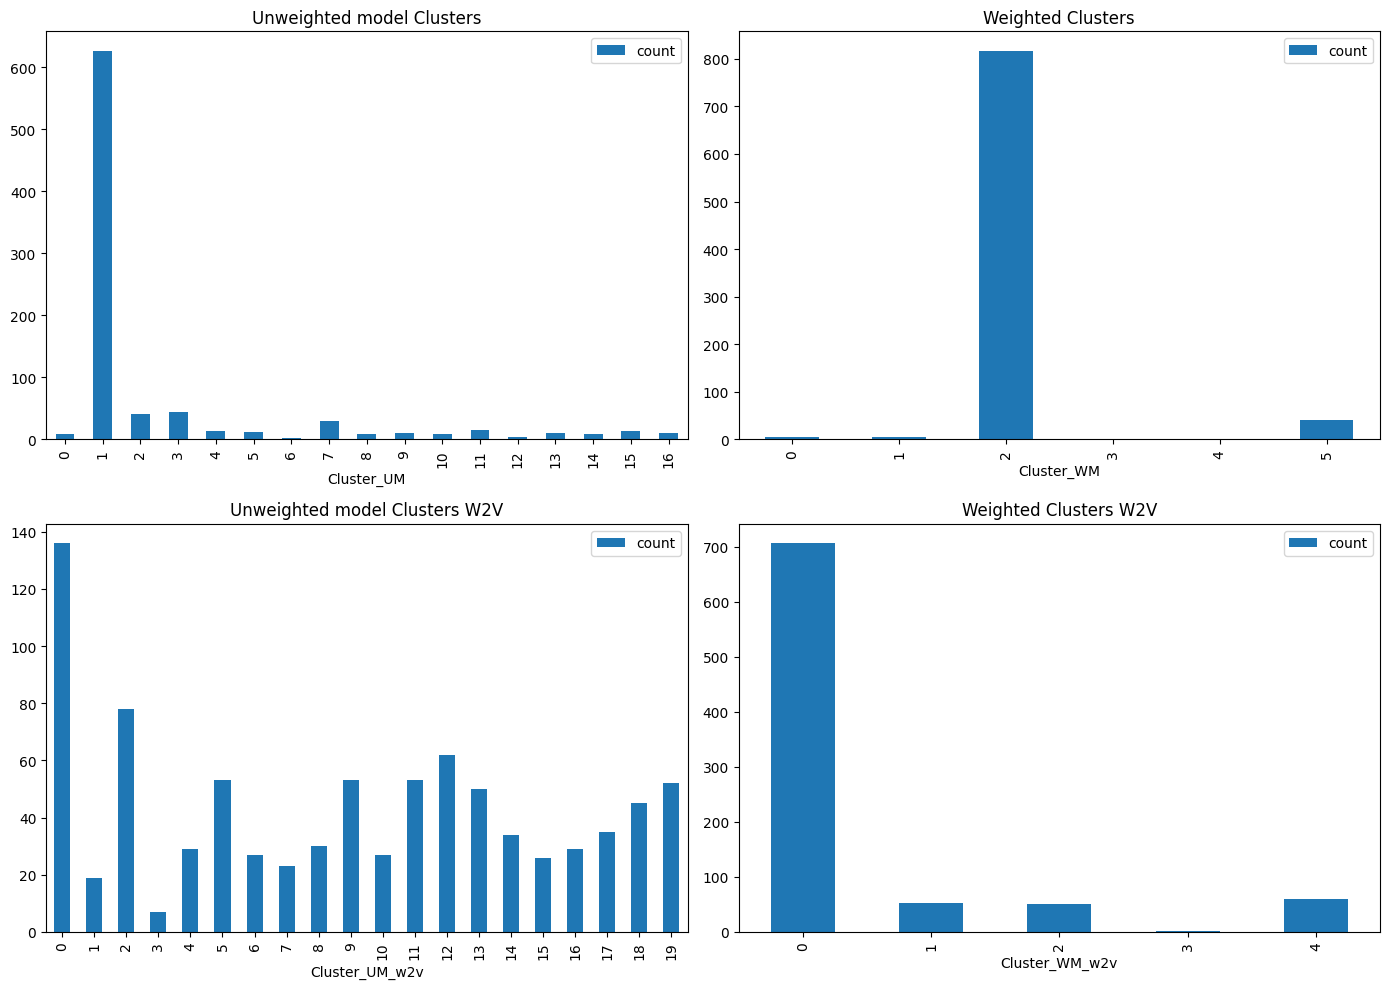

In [181]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

grouped_by_UM_clusters_unique_reasons.plot(kind='bar', ax=axes[0,0], title='Unweighted model Clusters')
grouped_by_WM_clusters_unique_reasons.plot(kind='bar', ax=axes[0,1], title='Weighted Clusters')

grouped_by_UM_w2v_clusters_unique_reasons.plot(kind='bar', ax=axes[1,0], title='Unweighted model Clusters W2V')
grouped_by_WM_w2v_clusters_unique_reasons.plot(kind='bar', ax=axes[1,1], title='Weighted Clusters W2V')

plt.tight_layout()
plt.show()

In [182]:
grouped_by_UM_w2v_clusters_unique_reasons.to_csv('grouped_by_UM_w2v_clusters_unique_reasons')